In [1]:
from capture_utils_v2 import CaptureSystem

# Initialize the capture system
system = CaptureSystem()


Pixel format set to RGB8
IC4 Grabber and Sink initialized.


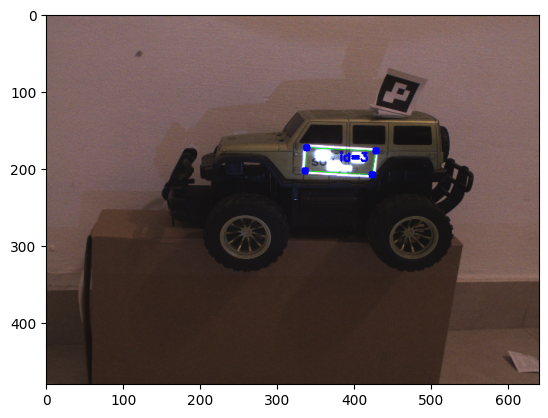

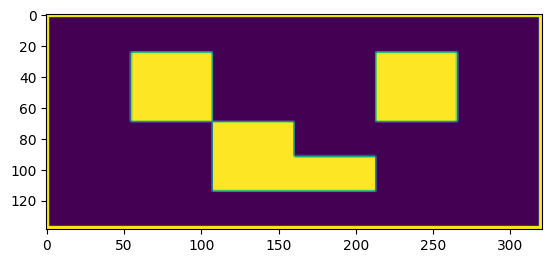

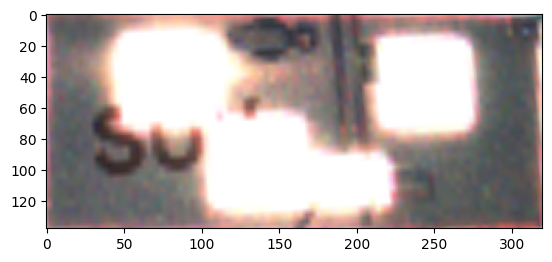

In [2]:
system.display_drawer()
system.run_aruco_detector()


In [3]:
import numpy as np


 12%|█▏        | 4/33 [00:06<00:46,  1.60s/it]

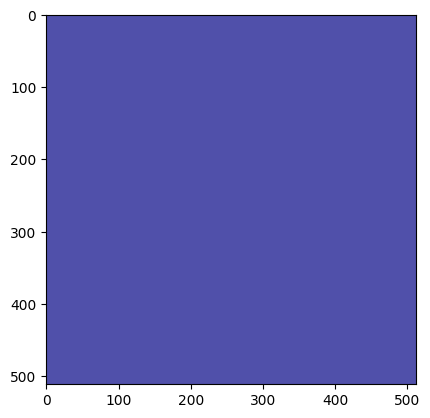

 12%|█▏        | 4/33 [00:07<00:56,  1.96s/it]



KeyboardInterrupt: 

In [4]:
system.photometric_calibration()

In [3]:
# save system orig_proj_corners and corners_img_proj to a file
import pickle
with open("capture_system_state.pkl", "wb") as f:
    pickle.dump((system.orig_proj_corners, system.corners_img_proj), f)

## Infer

In [4]:
from capture_utils_v2 import CaptureSystem
import cv2
import pickle

# Initialize the capture system
system = CaptureSystem()


IC4 already opened, using existing grabber and sink.


In [5]:
image_to_project =  cv2.imread(r'./results/best_patch_16x16_1_2025-12-14_21_56.png')

In [6]:
with open("capture_system_state.pkl", "rb") as f:
    system.orig_proj_corners, system.corners_img_proj = pickle.load(f)

In [7]:
# from classfier import *
from classfier import *
from tracking_utils import TrackerSystem
image_to_project =  patch = cv2.imread(r'C:\git\PhysicalAdverserialProj\results\best_patch_16x16_1_2025-12-13_16_22.png')

tracker = TrackerSystem(system, predict_raw, weights, printed_aruco_id=9)
caps, results = tracker.track_project_and_classify(image_to_project)

track_and_project() function defined!

Usage: track_and_project(system, your_image)
  - system: CaptureSystem object
  - your_image: numpy array of image to project
TrackerSystem class defined!

Usage:
  from classfier import *
  tracker = TrackerSystem(system, predict_raw, weights, printed_aruco_id=10)
  caps, results = tracker.track_project_and_classify(image_to_project)

Returns: (caps, results) - captured frames and classification results
TrackerSystem initialized!
=== TRACK, PROJECT, AND CLASSIFY ===
Waiting for calibration... Detecting printed marker...
Press 'q' to quit, 'r' to reset calibration
Calibration complete! Starting classification...
Tracking and classifying... Press 'q' to stop
Calibration complete! Starting classification...
Tracking and classifying... Press 'q' to stop
Classification ended. Captured 724 frames.
Classification ended. Captured 724 frames.


In [8]:
import imageio

captures = caps
# Create GIF from captures
captures_rgb = [cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) for frame in captures]
output_gif_path = 'tracked_jeep_16x16_1_2025-12-13_16_22_inception_v3.gif'
imageio.mimsave(output_gif_path, captures_rgb, fps=14, loop=0)
print(f"GIF saved to {output_gif_path} with {len(captures)} frames")

GIF saved to tracked_jeep_16x16_1_2025-12-13_16_22_inception_v3.gif with 724 frames
